In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)



In [ ]:

df = pd.read_csv("kc_house_data.csv")

<Axes: >

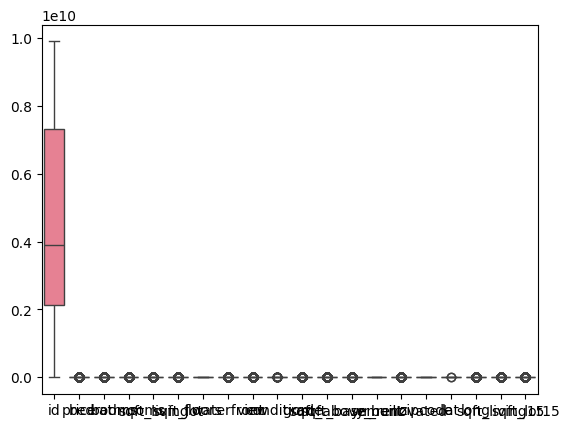

In [ ]:
import seaborn as sns
sns.boxplot(df)


In [ ]:
n=df.select_dtypes(include=['number','float']).columns.tolist()
for col in n:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  lower=q1-1.5*iqr
  upper=q3+1.5*iqr
  df[col]=df[col].clip(upper,lower)
df


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3.0,1.00,1180.0,5650,1.0,0,0,...,7.0,1180,0,1955,0,98178,47.5112,-122.257,1340,5650.0
1,6414100192,20141209T000000,538000.0,3.0,2.25,2570.0,7242,2.0,0,0,...,7.0,2170,400,1951,0,98125,47.7210,-122.319,1690,7639.0
2,5631500400,20150225T000000,180000.0,2.0,1.00,770.0,10000,1.0,0,0,...,6.0,770,0,1933,0,98028,47.7379,-122.233,2720,8062.0
3,2487200875,20141209T000000,604000.0,4.0,3.00,1960.0,5000,1.0,0,0,...,7.0,1050,910,1965,0,98136,47.5208,-122.393,1360,5000.0
4,1954400510,20150218T000000,510000.0,3.0,2.00,1680.0,8080,1.0,0,0,...,8.0,1680,0,1987,0,98074,47.6168,-122.045,1800,7503.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3.0,2.50,1530.0,1131,3.0,0,0,...,8.0,1530,0,2009,0,98103,47.6993,-122.346,1530,1509.0
21609,6600060120,20150223T000000,400000.0,4.0,2.50,2310.0,5813,2.0,0,0,...,8.0,2310,0,2014,0,98146,47.5107,-122.362,1830,7200.0
21610,1523300141,20140623T000000,402101.0,2.0,0.75,1020.0,1350,2.0,0,0,...,7.0,1020,0,2009,0,98144,47.5944,-122.299,1020,2007.0
21611,291310100,20150116T000000,400000.0,3.0,2.50,1600.0,2388,2.0,0,0,...,8.0,1600,0,2004,0,98027,47.5345,-122.069,1410,1287.0


In [ ]:

df = df.drop(['id', 'date'], axis=1)
x = df.drop('price', axis=1)
y = df['price']
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42
)


In [ ]:
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
y_pred = lr_model.predict(x_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE :", mae)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mse))

R2 Score: 0.7395878582874846
MAE : 97868.34080251548
Mean Squared Error: 16708684822.345709
RMSE : 129262.07805209426
